# S04b_Independent_Samples_t_Test

We have a slightly different formula to calculate the $t$ statistic for the two sample case, yet the process is remarkedly similar.

## Uses of $t$-Tests

1. We use the **$t$-Test** to compare a subgroup mean to an overall population mean.
2. We use the **Independent Samples $t$-Test** to compare the means from two subgroups directly to one another.

We have a version of the $t$-test we use for **pretest vs. posttest** research desgins, and we will cover that next.

## Data Checks for Independent Samples $t$-Tests

We conduct the same **data checks** as with the $t$-Test, but we do so for <span style = 'color:blue;font-weight:bold'>both samples</span>.

- Box plots -- no outliers unless $n\geq 40$
- Density plots -- both approximately normal.

For sample size here, we use the overall sample size $n=n_1+n_2$.<br><br>

For **homogeneity of the variances** (e.g. equal standard deviations), we require instead that the ratio of smallest to largest samples is no more than $2:1$. Given this additional requirement, a difference in standard deviations will not seriously erode the accuracy of the test.

## Example 1: Narcissism and Biological Sex

**Research Question.** Test for a difference in narcissism levels between biological males and biological females at the $\alpha = 0.01$ level of significance.

The data frame is loaded and subsetting is conducted below to create the two samples:

- f_narc
- m_narc

In [7]:
pers <- read.csv('https://faculty.ung.edu/rsinn/data/personality.csv')
m_narc <- subset(pers, Sex == 'M')$Narc
f_narc <- subset(pers, Sex == 'F')$Narc

**Hypothesis**

- $H_0 : \mu_m = \mu_f$
- $H_a : \mu_m > \mu_f$

**Data Checks**
Males

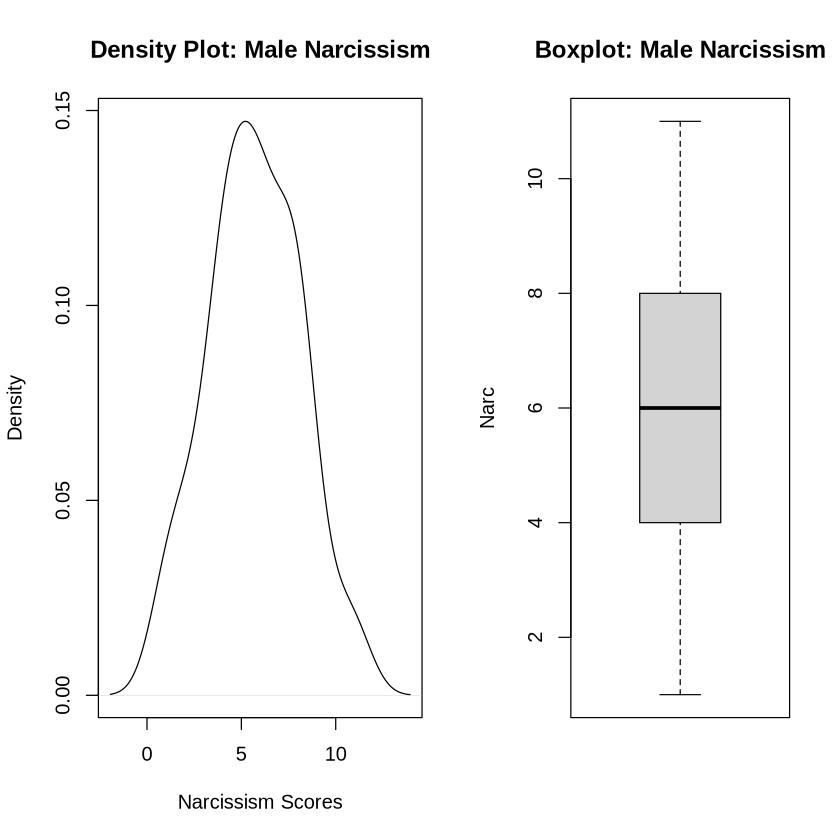

In [8]:
# Using layout() and matrix() to create grid.
layout(matrix(c(1,2), ncol = 2), lcm(10))
plot(density(m_narc), main = 'Density Plot: Male Narcissism', xlab = 'Narcissism Scores')
boxplot(m_narc, main = 'Boxplot: Male Narcissism', ylab = 'Narc')

**Data Checks**
Females

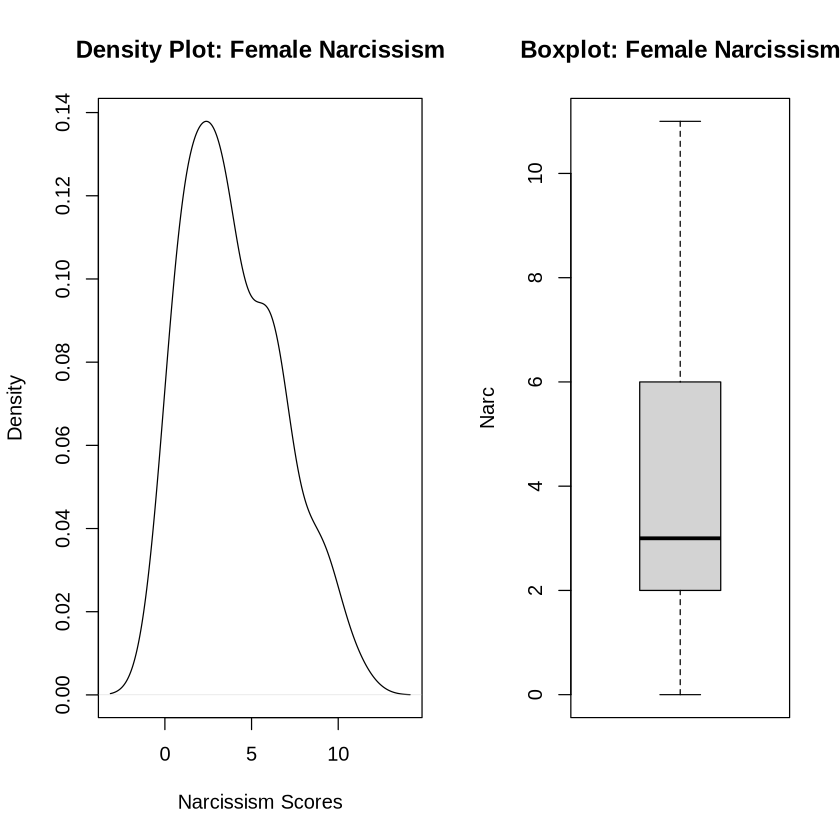

In [9]:
# Using layout() and matrix() to create grid.
layout(matrix(c(1,2), ncol = 2), lcm(10))
plot(density(f_narc), main = 'Density Plot: Female Narcissism', xlab = 'Narcissism Scores')
boxplot(f_narc, main = 'Boxplot: Female Narcissism', ylab = 'Narc')

We find that both samples appear to be normally distributed, and that neither have outliers. Thus, these data are appropriate for $t$-procedures.

In [11]:
t.test(f_narc, m_narc)


	Welch Two Sample t-test

data:  f_narc and m_narc
t = -3.8124, df = 123.31, p-value = 0.0002162
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -2.6509516 -0.8389747
sample estimates:
mean of x mean of y 
 3.945946  5.690909 


**Reporting Out**

Because $p=0.00022 < 0.01 = \alpha$, we reject the null. We thus have evidence that males at UNG have a higher level of narcissism (on average) than females.

##### Example 2: Birth Weights of Babies

Test at the 0.025 level whether babies born to moms who smoke during pregnancy weigh less, on average, than babies born to non-smoking moms.

In [2]:
births <- read.csv('https://faculty.ung.edu/rsinn/data/baby.csv')
smoke <- subset(births, Maternal.Smoker == 'True')$Birth.Weight
non <- subset(births, Maternal.Smoker == 'False')$Birth.Weight

**Hyothesis**

- $H_0 : \mu_s = \mu_n$
- $H_a : \mu_s < \mu_n$

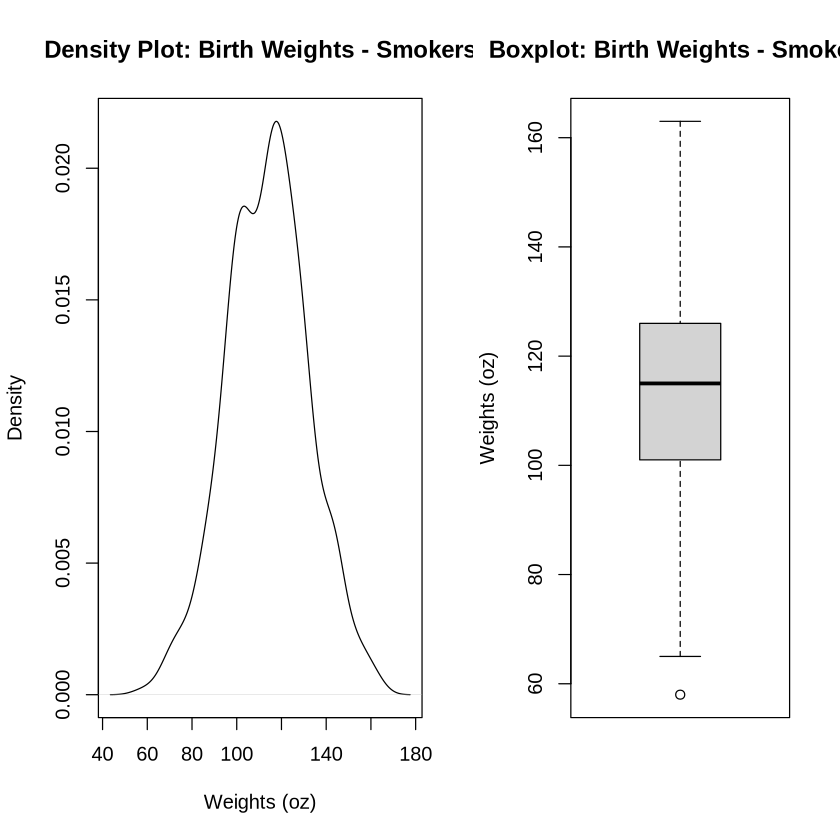

In [3]:
# Using layout() and matrix() to create grid.
layout(matrix(c(1,2), ncol = 2), lcm(10))
plot(density(smoke), main = 'Density Plot: Birth Weights - Smokers', xlab = 'Weights (oz)')
boxplot(smoke, main = 'Boxplot: Birth Weights - Smokers', ylab = 'Weights (oz)')

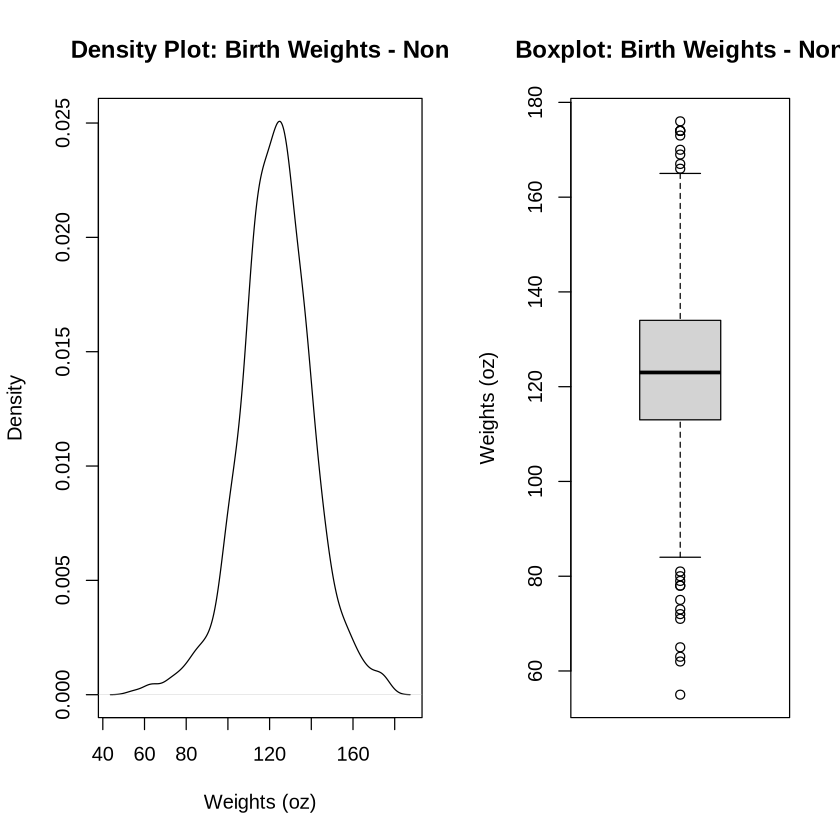

In [4]:
# Using layout() and matrix() to create grid.
layout(matrix(c(1,2), ncol = 2), lcm(10))
plot(density(non), main = 'Density Plot: Birth Weights - Non', xlab = 'Weights (oz)')
boxplot(non, main = 'Boxplot: Birth Weights - Non', ylab = 'Weights (oz)')

**Data Checks**

Both data sets are approximately normal (bell-shaped) with balanced outliers for non-smokers and only one outlier for smokers. These data are appropriate for $t$-procedures.

Also, the ratio of group sizes is less than 2:1.

In [11]:
length(non)

[1] 715

In [12]:
length(smoke)

[1] 459

In [13]:
t.test(smoke, non, alternative = 'l')


	Welch Two Sample t-test

data:  smoke and non
t = -8.6265, df = 941.81, p-value < 2.2e-16
alternative hypothesis: true difference in means is less than 0
95 percent confidence interval:
      -Inf -7.497579
sample estimates:
mean of x mean of y 
 113.8192  123.0853 


Since $p=2.2\times 10^{-16} < 0.025 =\alpha$, we reject the null. We thus have evidence that the birth weights in the non-smoking moms group was greater than that in the smoking moms group.

## Example 3: Flight Delays

In the **united** data frame, test at $\alpha = 0.05$ level whether the flight delays when the destination is Atlanta (ATL) are shorter than the flight delays when the destination is Dallas Fort Worth (DFW).

In [14]:
united <- read.csv('https://faculty.ung.edu/rsinn/data/united.csv')
atl <- subset(united, Destination == 'ATL')$Delay
dfw <- subset(united, Destination == 'DFW')$Delay

**Hypothesis**
- $H_0 : \mu_a = \mu_d$
- $H_a : \mu_a < \mu_d$

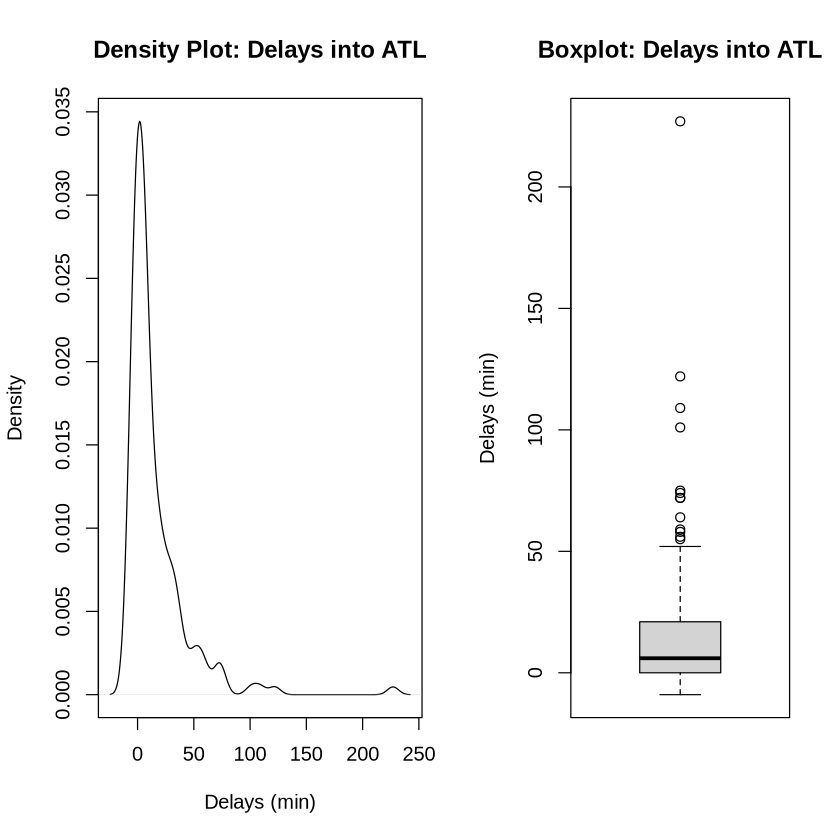

In [16]:
# Using layout() and matrix() to create grid.
layout(matrix(c(1,2), ncol = 2), lcm(10))
plot(density(atl), main = 'Density Plot: Delays into ATL', xlab = 'Delays (min)')
boxplot(atl, main = 'Boxplot: Delays into ATL', ylab = 'Delays (min)')

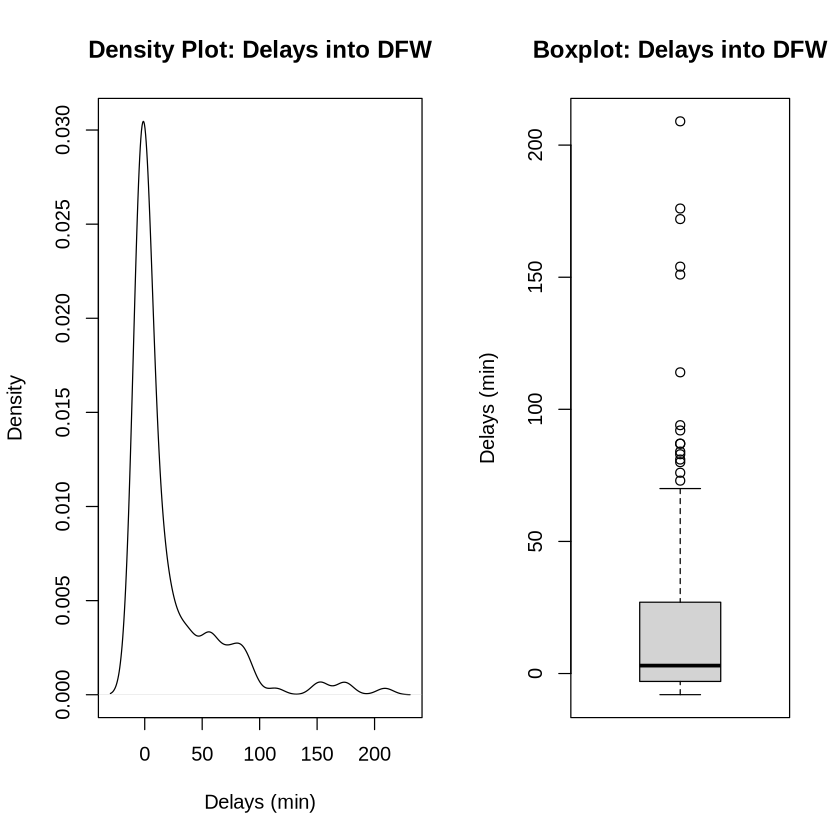

In [17]:
# Using layout() and matrix() to create grid.
layout(matrix(c(1,2), ncol = 2), lcm(10))
plot(density(dfw), main = 'Density Plot: Delays into DFW', xlab = 'Delays (min)')
boxplot(dfw, main = 'Boxplot: Delays into DFW', ylab = 'Delays (min)')

**Data Checks**

Both data sets are skewed massively to the right and have multiple outliers to the right with no outliers to the left.

The skew is too severe in both data sets. Therefore, these data are **not appropriate** for $t$-procedures.